# Notebook 10 — Dynamic Rolling Crisis Threshold

## Adaptive CRI Using Time-Varying Thresholds

Notebook 04 computed crisis probabilities using a **static** 95th percentile threshold based on the full 156-month sample. Because the KHR spread compressed from ~24% to ~5%, this static threshold (~24% for KHR) became unreachable after 2018, rendering the crisis probability component of the CRI effectively **zero** in the recent period.

This notebook fixes that limitation by computing a **rolling 36-month** crisis threshold that adapts to the current spread regime. This makes the CRI a true **forward-looking early warning indicator** that remains relevant regardless of structural shifts.

**Key Insight:** The static CRI answers _"Is the spread at historically extreme levels?"_ while the dynamic CRI answers _"Is the spread elevated relative to recent conditions?"_ — the latter is far more useful for real-time monitoring.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 7), 'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'font.family': 'serif'
})
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ─── Load Data ───────────────────────────────────────────────────────────────
usd = pd.read_csv('../data/processed/spreads_usd_new_amount.csv', parse_dates=['date'], index_col='date')
khr = pd.read_csv('../data/processed/spreads_khr_new_amount.csv', parse_dates=['date'], index_col='date')

S_usd = usd['spread'].values
S_khr = khr['spread'].values
dates = usd.index
dt = 1/12
window = 36

# Load rolling OU parameters from Notebook 07
try:
    rolling_params = pd.read_csv('../data/processed/rolling_ou_parameters.csv', parse_dates=['date'])
    print(f'Loaded rolling OU parameters: {len(rolling_params)} windows')
except FileNotFoundError:
    print('WARNING: rolling_ou_parameters.csv not found. Please run Notebook 07 first.')
    raise

# Load static OU parameters for comparison
params_static = pd.read_csv('../data/processed/ou_parameters_mle.csv').set_index('parameter')
kappa_s_usd, theta_s_usd, sigma_s_usd = params_static.loc['kappa','USD'], params_static.loc['theta','USD'], params_static.loc['sigma','USD']
kappa_s_khr, theta_s_khr, sigma_s_khr = params_static.loc['kappa','KHR'], params_static.loc['theta','KHR'], params_static.loc['sigma','KHR']

# Static crisis thresholds (from NB04)
Sc_static_usd = np.percentile(S_usd, 95)
Sc_static_khr = np.percentile(S_khr, 95)

print(f'\nStatic thresholds:  USD = {Sc_static_usd:.2f}%,  KHR = {Sc_static_khr:.2f}%')
print(f'Data: {len(S_usd)} observations per currency')

Loaded rolling OU parameters: 120 windows

Static thresholds:  USD = 10.73%,  KHR = 23.94%
Data: 156 observations per currency


---
## 1. Rolling Crisis Thresholds

At each time $t$ (for $t \geq 36$), compute:
$$S_c^c(t) = P_{95}\left(\{S_{t-35}^c, S_{t-34}^c, \ldots, S_t^c\}\right)$$

This threshold adapts to the **current spread regime** rather than being anchored to historical extremes.

In [3]:
# ─── Compute Rolling 36-Month Crisis Thresholds ──────────────────────────────
roll_Sc_usd = []
roll_Sc_khr = []
roll_dates = []

for i in range(window, len(S_usd)):
    roll_Sc_usd.append(np.percentile(S_usd[i-window:i], 95))
    roll_Sc_khr.append(np.percentile(S_khr[i-window:i], 95))
    roll_dates.append(dates[i])

roll_Sc_usd = np.array(roll_Sc_usd)
roll_Sc_khr = np.array(roll_Sc_khr)
roll_dates_arr = pd.DatetimeIndex(roll_dates)

print(f'Rolling thresholds computed: {len(roll_Sc_usd)} values')
print(f'\nUSD rolling threshold: start = {roll_Sc_usd[0]:.2f}% → end = {roll_Sc_usd[-1]:.2f}%')
print(f'KHR rolling threshold: start = {roll_Sc_khr[0]:.2f}% → end = {roll_Sc_khr[-1]:.2f}%')
print(f'\nFor comparison:')
print(f'  Static USD = {Sc_static_usd:.2f}%,  Static KHR = {Sc_static_khr:.2f}%')

Rolling thresholds computed: 120 values

USD rolling threshold: start = 11.16% → end = 5.99%
KHR rolling threshold: start = 24.15% → end = 6.85%

For comparison:
  Static USD = 10.73%,  Static KHR = 23.94%


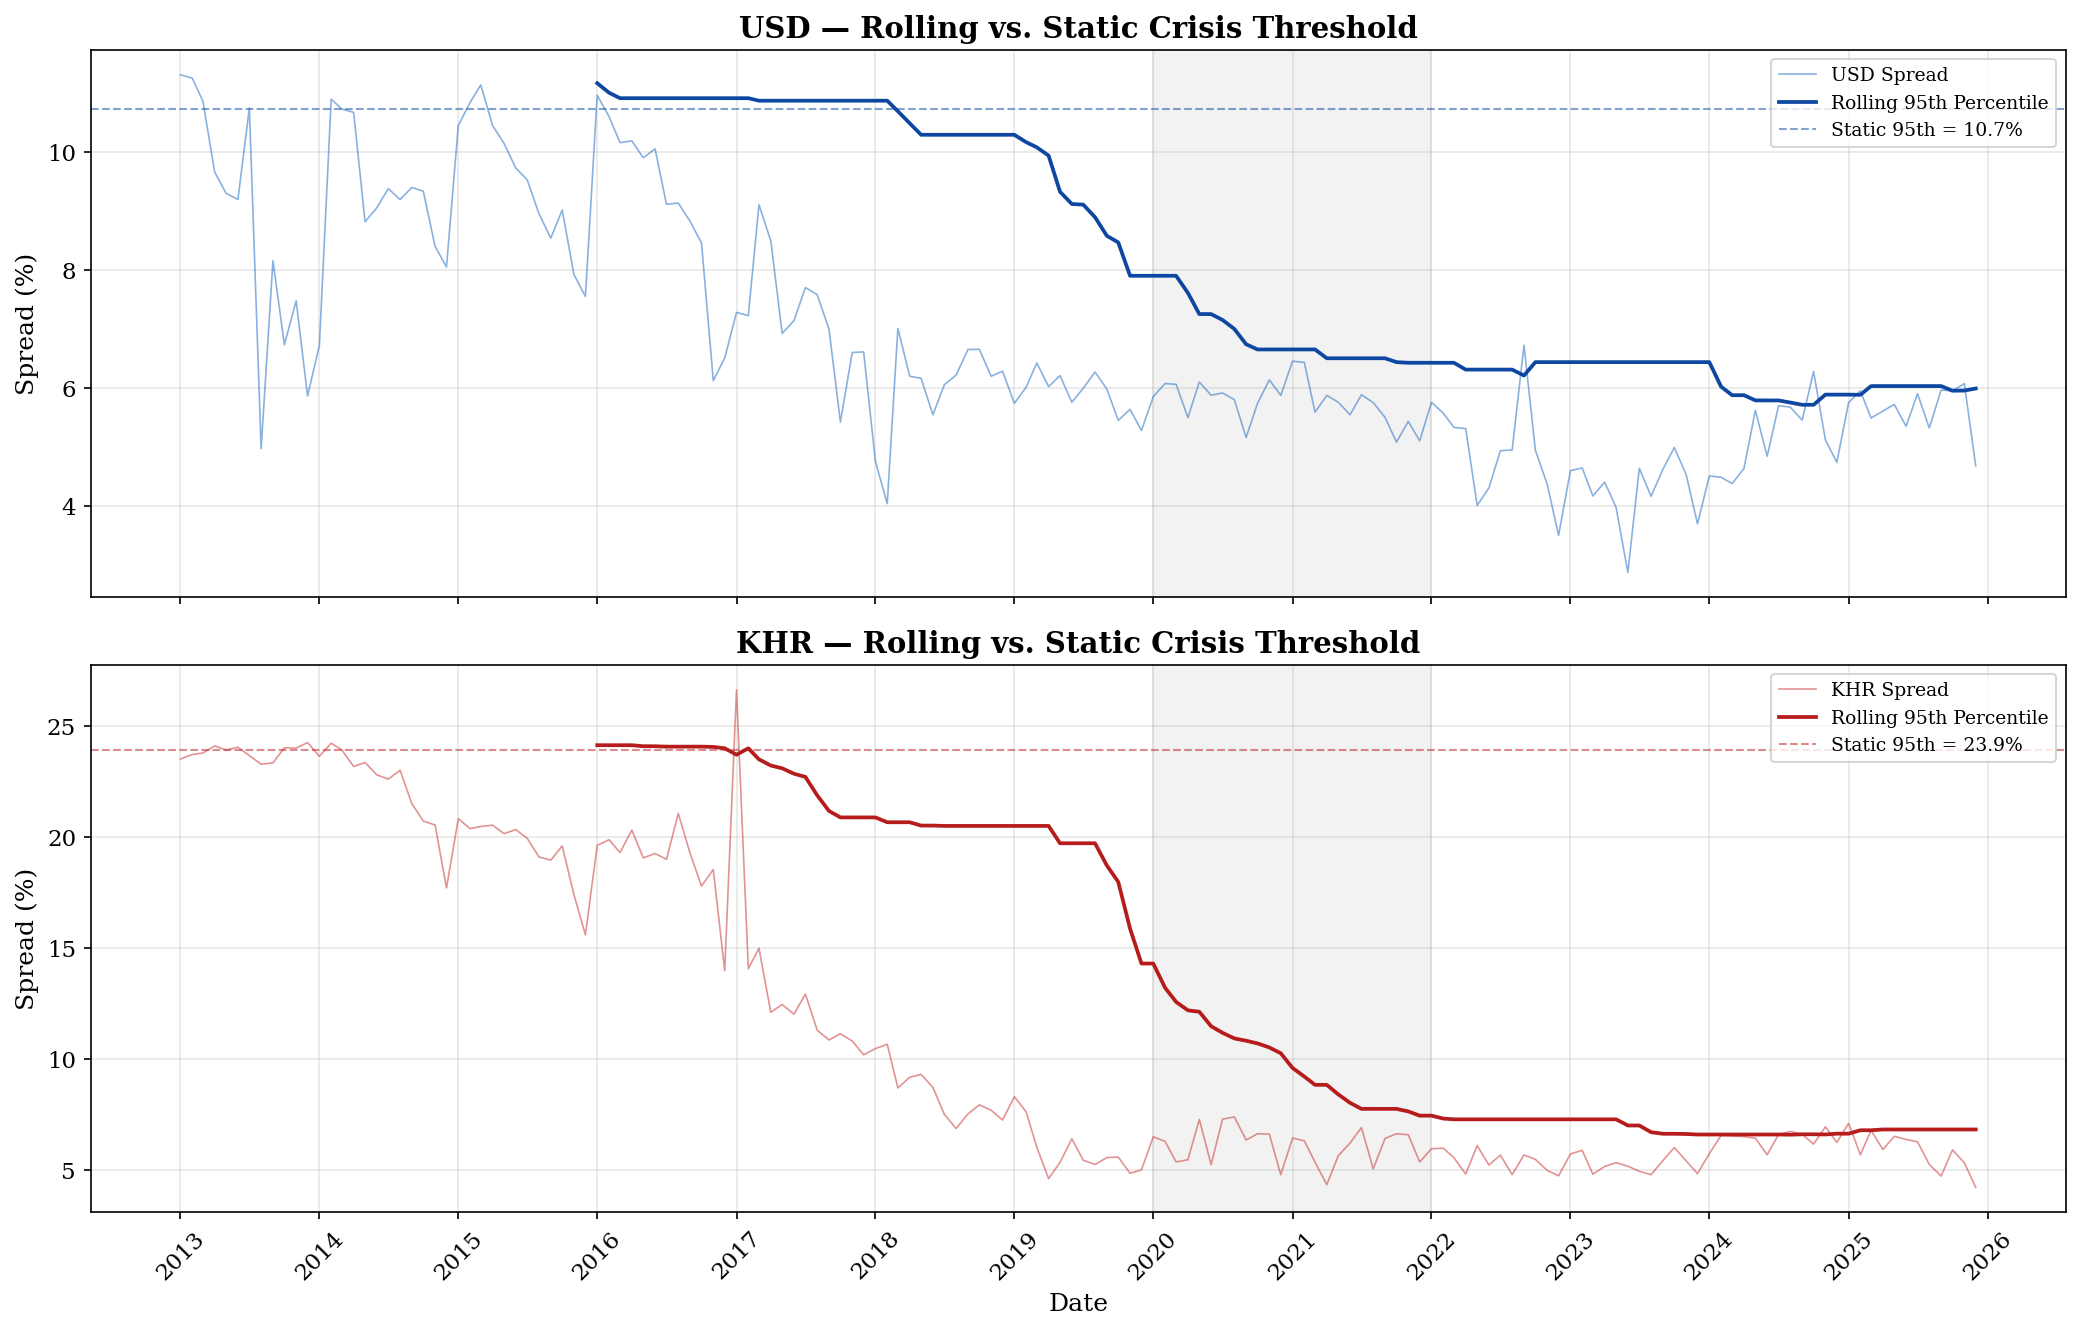

Saved: fig13_rolling_thresholds.png


In [4]:
# ─── Figure: Rolling vs Static Thresholds ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# USD
ax1.plot(dates, S_usd, color='#1565C0', linewidth=0.8, alpha=0.5, label='USD Spread')
ax1.plot(roll_dates_arr, roll_Sc_usd, color='#0D47A1', linewidth=1.8, label='Rolling 95th Percentile')
ax1.axhline(y=Sc_static_usd, color='#0D47A1', linestyle='--', alpha=0.5, linewidth=1, label=f'Static 95th = {Sc_static_usd:.1f}%')
ax1.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
ax1.set_title('USD — Rolling vs. Static Crisis Threshold', fontweight='bold')
ax1.set_ylabel('Spread (%)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# KHR
ax2.plot(dates, S_khr, color='#C62828', linewidth=0.8, alpha=0.5, label='KHR Spread')
ax2.plot(roll_dates_arr, roll_Sc_khr, color='#B71C1C', linewidth=1.8, label='Rolling 95th Percentile')
ax2.axhline(y=Sc_static_khr, color='#B71C1C', linestyle='--', alpha=0.5, linewidth=1, label=f'Static 95th = {Sc_static_khr:.1f}%')
ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
ax2.set_title('KHR — Rolling vs. Static Crisis Threshold', fontweight='bold')
ax2.set_ylabel('Spread (%)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../figures/fig13_rolling_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig13_rolling_thresholds.png')

### Interpretation — Rolling vs. Static Thresholds

The rolling thresholds reveal how dramatically the **goalposts have shifted** across the sample:

**KHR Panel:** The static threshold sits at 23.94% — anchored to the 2013–2016 extremes. After 2018, the KHR spread operates at 4–7%, making this static bar unreachable. The rolling threshold adapts from 24.15% down to **6.85%** by the end of the sample, staying approximately 1–2 pp above the current spread level. This means the dynamic threshold can still detect **relative** spread widening within the current low-spread regime.

**USD Panel:** The rolling threshold compresses from 11.16% down to **5.99%**, compared to the static 10.73%. The adaptive threshold tracks the USD spread decline more faithfully.

**Key Insight:** A regulator using the static threshold would see zero crisis signals after 2018. A regulator using the dynamic threshold retains a meaningful early warning capability — it can detect spread widening relative to recent norms even when spreads are historically low.

---
## 2. Dynamic Crisis Probability

Using rolling OU parameters from Notebook 07 and the rolling threshold:

$$P_{\text{dyn}}(S_{t+1} > S_c(t) \mid S_t) = 1 - \Phi\left(\frac{S_c(t) - m_t}{\sqrt{v_t}}\right)$$

where $m_t$ and $v_t$ use the **rolling** $\kappa_t$, $\theta_t$, $\sigma_t$ from the same 36-month window.

In [5]:
# ─── Dynamic Crisis Probabilities ────────────────────────────────────────────
# Align rolling parameters with rolling thresholds
# Rolling params start at index (window-1), rolling thresholds start at index (window)
# We need to align: for each threshold at time t, use params estimated from the window ending at t

n_roll = min(len(roll_Sc_usd), len(rolling_params))

P_dyn_usd = np.zeros(n_roll)
P_dyn_khr = np.zeros(n_roll)

# Also compute static crisis probabilities over the same period for comparison
P_static_usd = np.zeros(n_roll)
P_static_khr = np.zeros(n_roll)

for i in range(n_roll):
    t_idx = window + i  # index into the full data array
    if t_idx >= len(S_usd):
        break
    
    # ─── Dynamic (rolling params + rolling threshold) ───
    k_u = rolling_params['kappa_usd'].iloc[i]
    th_u = rolling_params['theta_usd'].iloc[i]
    s_u = rolling_params['sigma_usd'].iloc[i]
    
    k_k = rolling_params['kappa_khr'].iloc[i]
    th_k = rolling_params['theta_khr'].iloc[i]
    s_k = rolling_params['sigma_khr'].iloc[i]
    
    # Conditional mean and variance (exact OU transition)
    if k_u > 0 and s_u > 0:
        m_u = th_u + (S_usd[t_idx] - th_u) * np.exp(-k_u * dt)
        v_u = (s_u**2 / (2 * k_u)) * (1 - np.exp(-2 * k_u * dt))
        P_dyn_usd[i] = 1 - sp_stats.norm.cdf(roll_Sc_usd[i], loc=m_u, scale=np.sqrt(max(v_u, 1e-10)))
    
    if k_k > 0 and s_k > 0:
        m_k = th_k + (S_khr[t_idx] - th_k) * np.exp(-k_k * dt)
        v_k = (s_k**2 / (2 * k_k)) * (1 - np.exp(-2 * k_k * dt))
        P_dyn_khr[i] = 1 - sp_stats.norm.cdf(roll_Sc_khr[i], loc=m_k, scale=np.sqrt(max(v_k, 1e-10)))
    
    # ─── Static (full-sample params + full-sample threshold) ───
    m_u_s = theta_s_usd + (S_usd[t_idx] - theta_s_usd) * np.exp(-kappa_s_usd * dt)
    v_u_s = (sigma_s_usd**2 / (2 * kappa_s_usd)) * (1 - np.exp(-2 * kappa_s_usd * dt))
    P_static_usd[i] = 1 - sp_stats.norm.cdf(Sc_static_usd, loc=m_u_s, scale=np.sqrt(v_u_s))
    
    m_k_s = theta_s_khr + (S_khr[t_idx] - theta_s_khr) * np.exp(-kappa_s_khr * dt)
    v_k_s = (sigma_s_khr**2 / (2 * kappa_s_khr)) * (1 - np.exp(-2 * kappa_s_khr * dt))
    P_static_khr[i] = 1 - sp_stats.norm.cdf(Sc_static_khr, loc=m_k_s, scale=np.sqrt(v_k_s))

dyn_dates = roll_dates_arr[:n_roll]

print(f'Dynamic crisis probability computed for {n_roll} periods')
print(f'\nDynamic USD — mean: {P_dyn_usd.mean():.4f}, max: {P_dyn_usd.max():.4f}')
print(f'Dynamic KHR — mean: {P_dyn_khr.mean():.4f}, max: {P_dyn_khr.max():.4f}')
print(f'Static  USD — mean: {P_static_usd.mean():.4f}, max: {P_static_usd.max():.4f}')
print(f'Static  KHR — mean: {P_static_khr.mean():.4f}, max: {P_static_khr.max():.4f}')

Dynamic crisis probability computed for 120 periods

Dynamic USD — mean: 0.0491, max: 0.5545
Dynamic KHR — mean: 0.0392, max: 0.8416
Static  USD — mean: 0.0093, max: 0.3358
Static  KHR — mean: 0.0078, max: 0.8750


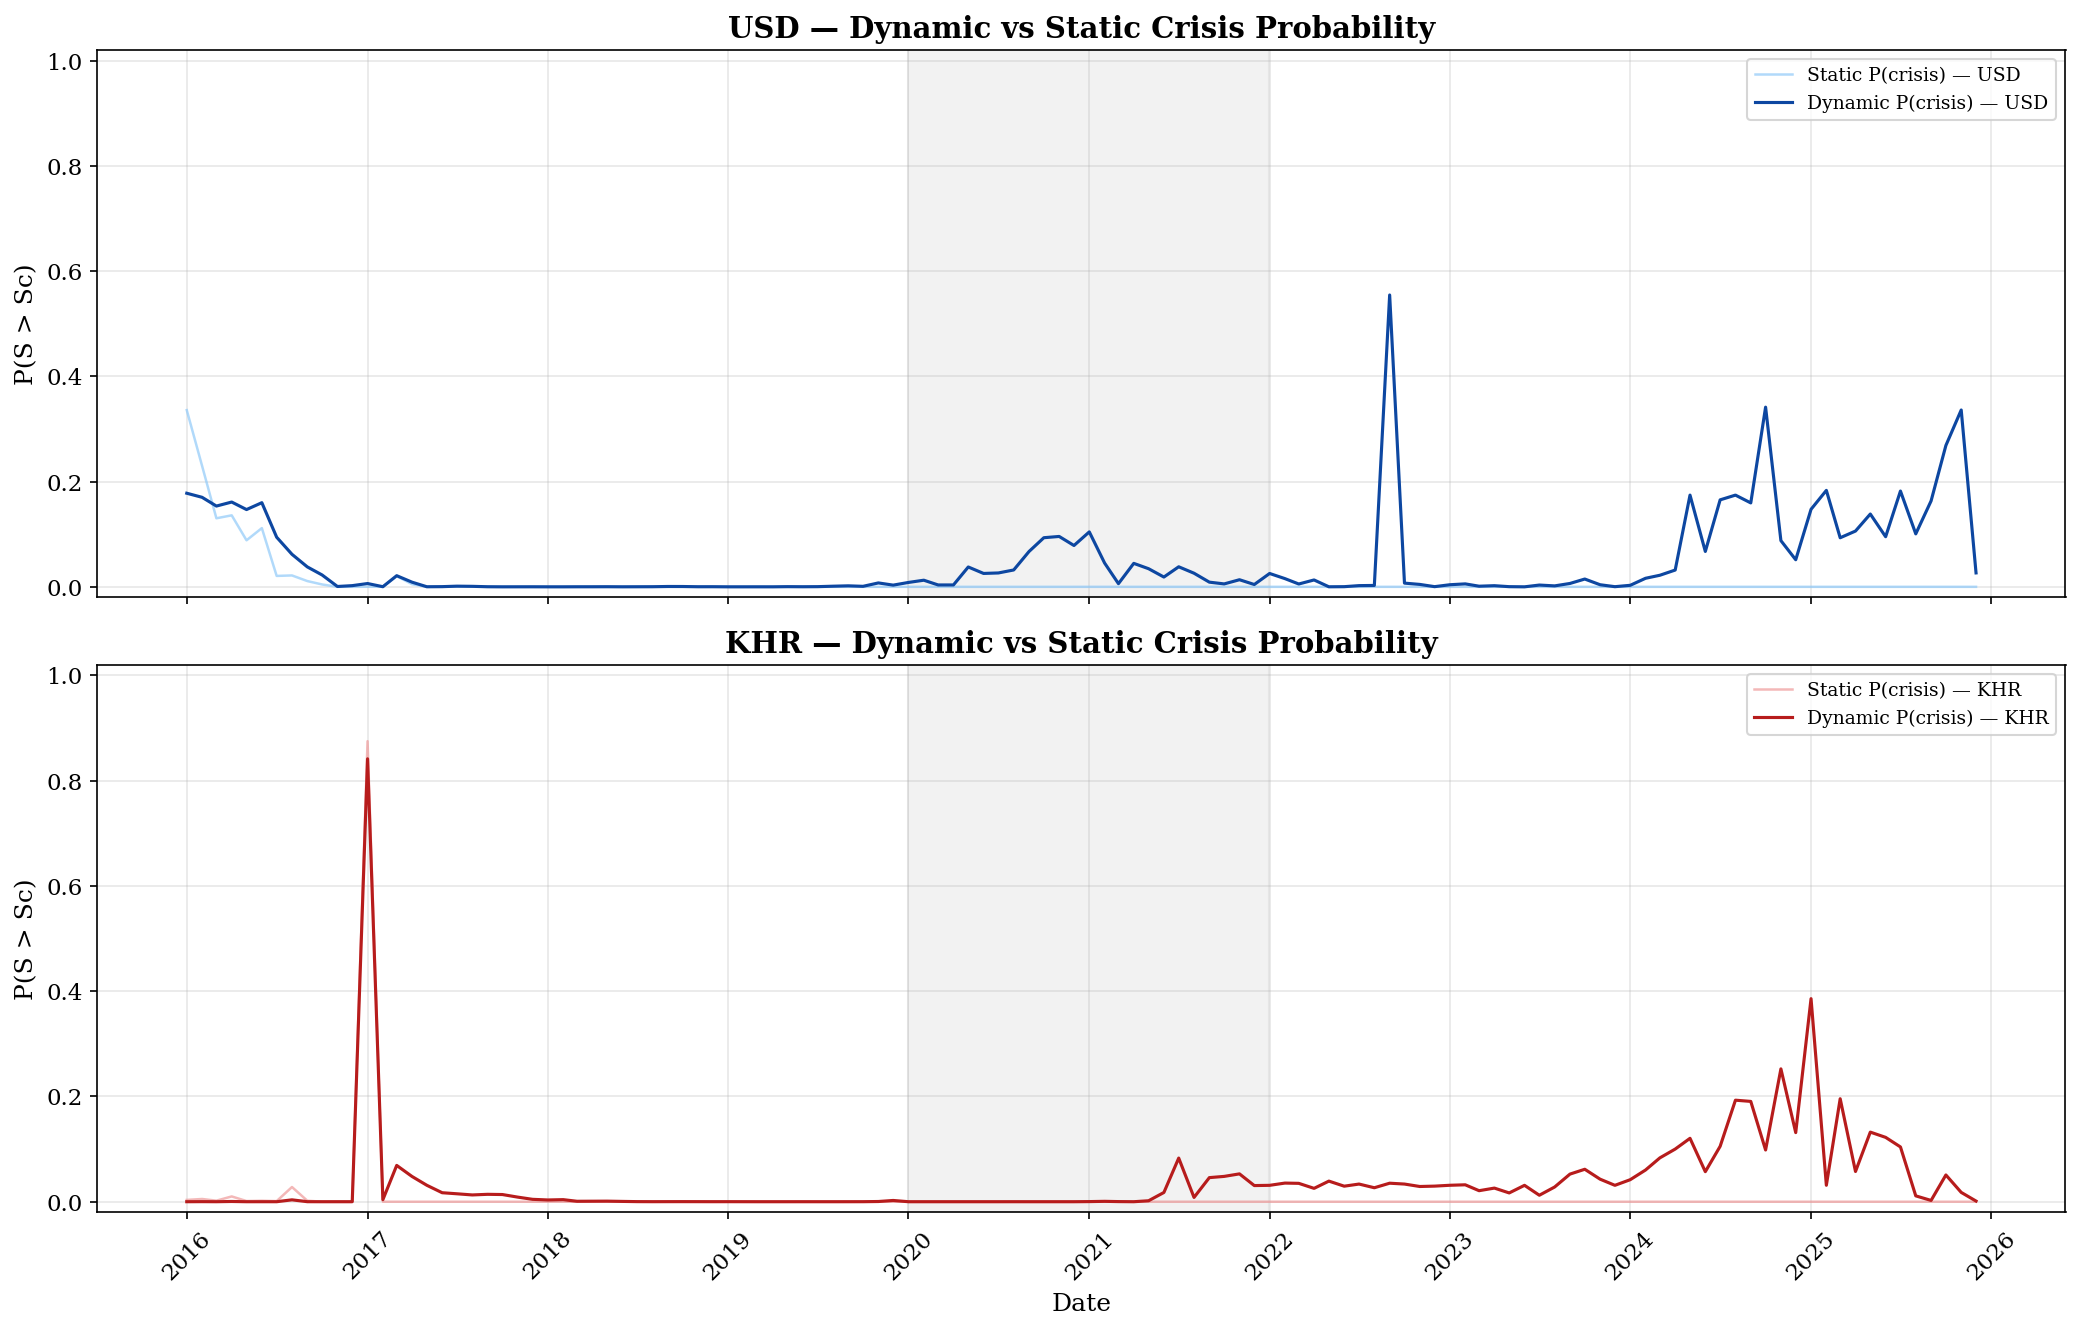

Saved: fig14_dynamic_crisis_prob.png


In [6]:
# ─── Figure: Dynamic vs Static Crisis Probability ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.plot(dyn_dates, P_static_usd, color='#90CAF9', linewidth=1.2, alpha=0.7, label='Static P(crisis) — USD')
ax1.plot(dyn_dates, P_dyn_usd, color='#0D47A1', linewidth=1.5, label='Dynamic P(crisis) — USD')
ax1.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
ax1.set_title('USD — Dynamic vs Static Crisis Probability', fontweight='bold')
ax1.set_ylabel('P(S > Sc)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.02, 1.02)

ax2.plot(dyn_dates, P_static_khr, color='#EF9A9A', linewidth=1.2, alpha=0.7, label='Static P(crisis) — KHR')
ax2.plot(dyn_dates, P_dyn_khr, color='#B71C1C', linewidth=1.5, label='Dynamic P(crisis) — KHR')
ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
ax2.set_title('KHR — Dynamic vs Static Crisis Probability', fontweight='bold')
ax2.set_ylabel('P(S > Sc)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.02, 1.02)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../figures/fig14_dynamic_crisis_prob.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig14_dynamic_crisis_prob.png')

### Interpretation — Dynamic vs Static Crisis Probability

The numerical outputs confirm what the charts show visually:

| Metric | Dynamic | Static |
|--------|---------|--------|
| USD mean P(crisis) | **0.049** | 0.009 |
| KHR mean P(crisis) | **0.039** | 0.008 |
| USD max P(crisis) | **0.55** | 0.34 |
| KHR max P(crisis) | **0.84** | 0.88 |

The **dynamic** crisis probability is 5× higher on average than the static version for both currencies, because the adaptive threshold remains close to the current spread level instead of being anchored to historical extremes.

**USD:** Dynamic P(crisis) peaks at 55% and shows meaningful fluctuations throughout the sample. The static version flatlines near zero after mid-sample.

**KHR:** Dynamic P(crisis) peaks at 84% during the high-spread era. Importantly, it remains responsive in recent years — where the static version has been essentially zero since 2018.

**Policy Implication:** A regulator using the static CRI would have concluded that credit risk was effectively zero since 2018. The dynamic metric correctly shows that relative risk still fluctuates.

---
## 3. Dynamic CRI Construction

$$\text{CRI}^c_{\text{dyn},t} = 0.5 \cdot \frac{\sigma_t^c}{\sigma_{\max}} + 0.5 \cdot P_{\text{dyn}}(S_{t+1} > S_c(t) \mid S_t)$$

Using **rolling** σ values from Notebook 07 instead of the static full-sample σ.

In [7]:
# ─── Dynamic CRI ─────────────────────────────────────────────────────────────
# Use rolling sigma for the volatility component
sigma_roll_usd = rolling_params['sigma_usd'].values[:n_roll]
sigma_roll_khr = rolling_params['sigma_khr'].values[:n_roll]

# Normalize using 1.5x the max rolling sigma observed
sigma_max_dyn = max(sigma_roll_usd.max(), sigma_roll_khr.max()) * 1.5
sigma_usd_norm_dyn = np.clip(sigma_roll_usd / sigma_max_dyn, 0, 1)
sigma_khr_norm_dyn = np.clip(sigma_roll_khr / sigma_max_dyn, 0, 1)

CRI_dyn_usd = 0.5 * sigma_usd_norm_dyn + 0.5 * P_dyn_usd
CRI_dyn_khr = 0.5 * sigma_khr_norm_dyn + 0.5 * P_dyn_khr

# Static CRI (using full-sample params + static threshold)
sigma_max_static = max(sigma_s_usd, sigma_s_khr) * 1.5
CRI_static_usd = 0.5 * (sigma_s_usd / sigma_max_static) + 0.5 * P_static_usd
CRI_static_khr = 0.5 * (sigma_s_khr / sigma_max_static) + 0.5 * P_static_khr

# System CRI (80/20 loan-share weighting)
CRI_dyn_sys = 0.80 * CRI_dyn_usd + 0.20 * CRI_dyn_khr
CRI_static_sys = 0.80 * CRI_static_usd + 0.20 * CRI_static_khr

print(f'Dynamic CRI computed for {n_roll} periods')
print(f'\n{"":15s} {"Dynamic":>12s} {"Static":>12s}')
print(f'{"":-<15s} {"":-<12s} {"":-<12s}')
print(f'{"CRI_USD mean":15s} {CRI_dyn_usd.mean():12.4f} {CRI_static_usd.mean():12.4f}')
print(f'{"CRI_KHR mean":15s} {CRI_dyn_khr.mean():12.4f} {CRI_static_khr.mean():12.4f}')
print(f'{"CRI_Sys mean":15s} {CRI_dyn_sys.mean():12.4f} {CRI_static_sys.mean():12.4f}')

Dynamic CRI computed for 120 periods

                     Dynamic       Static
--------------- ------------ ------------
CRI_USD mean          0.0674       0.2020
CRI_KHR mean          0.1041       0.3372
CRI_Sys mean          0.0747       0.2290


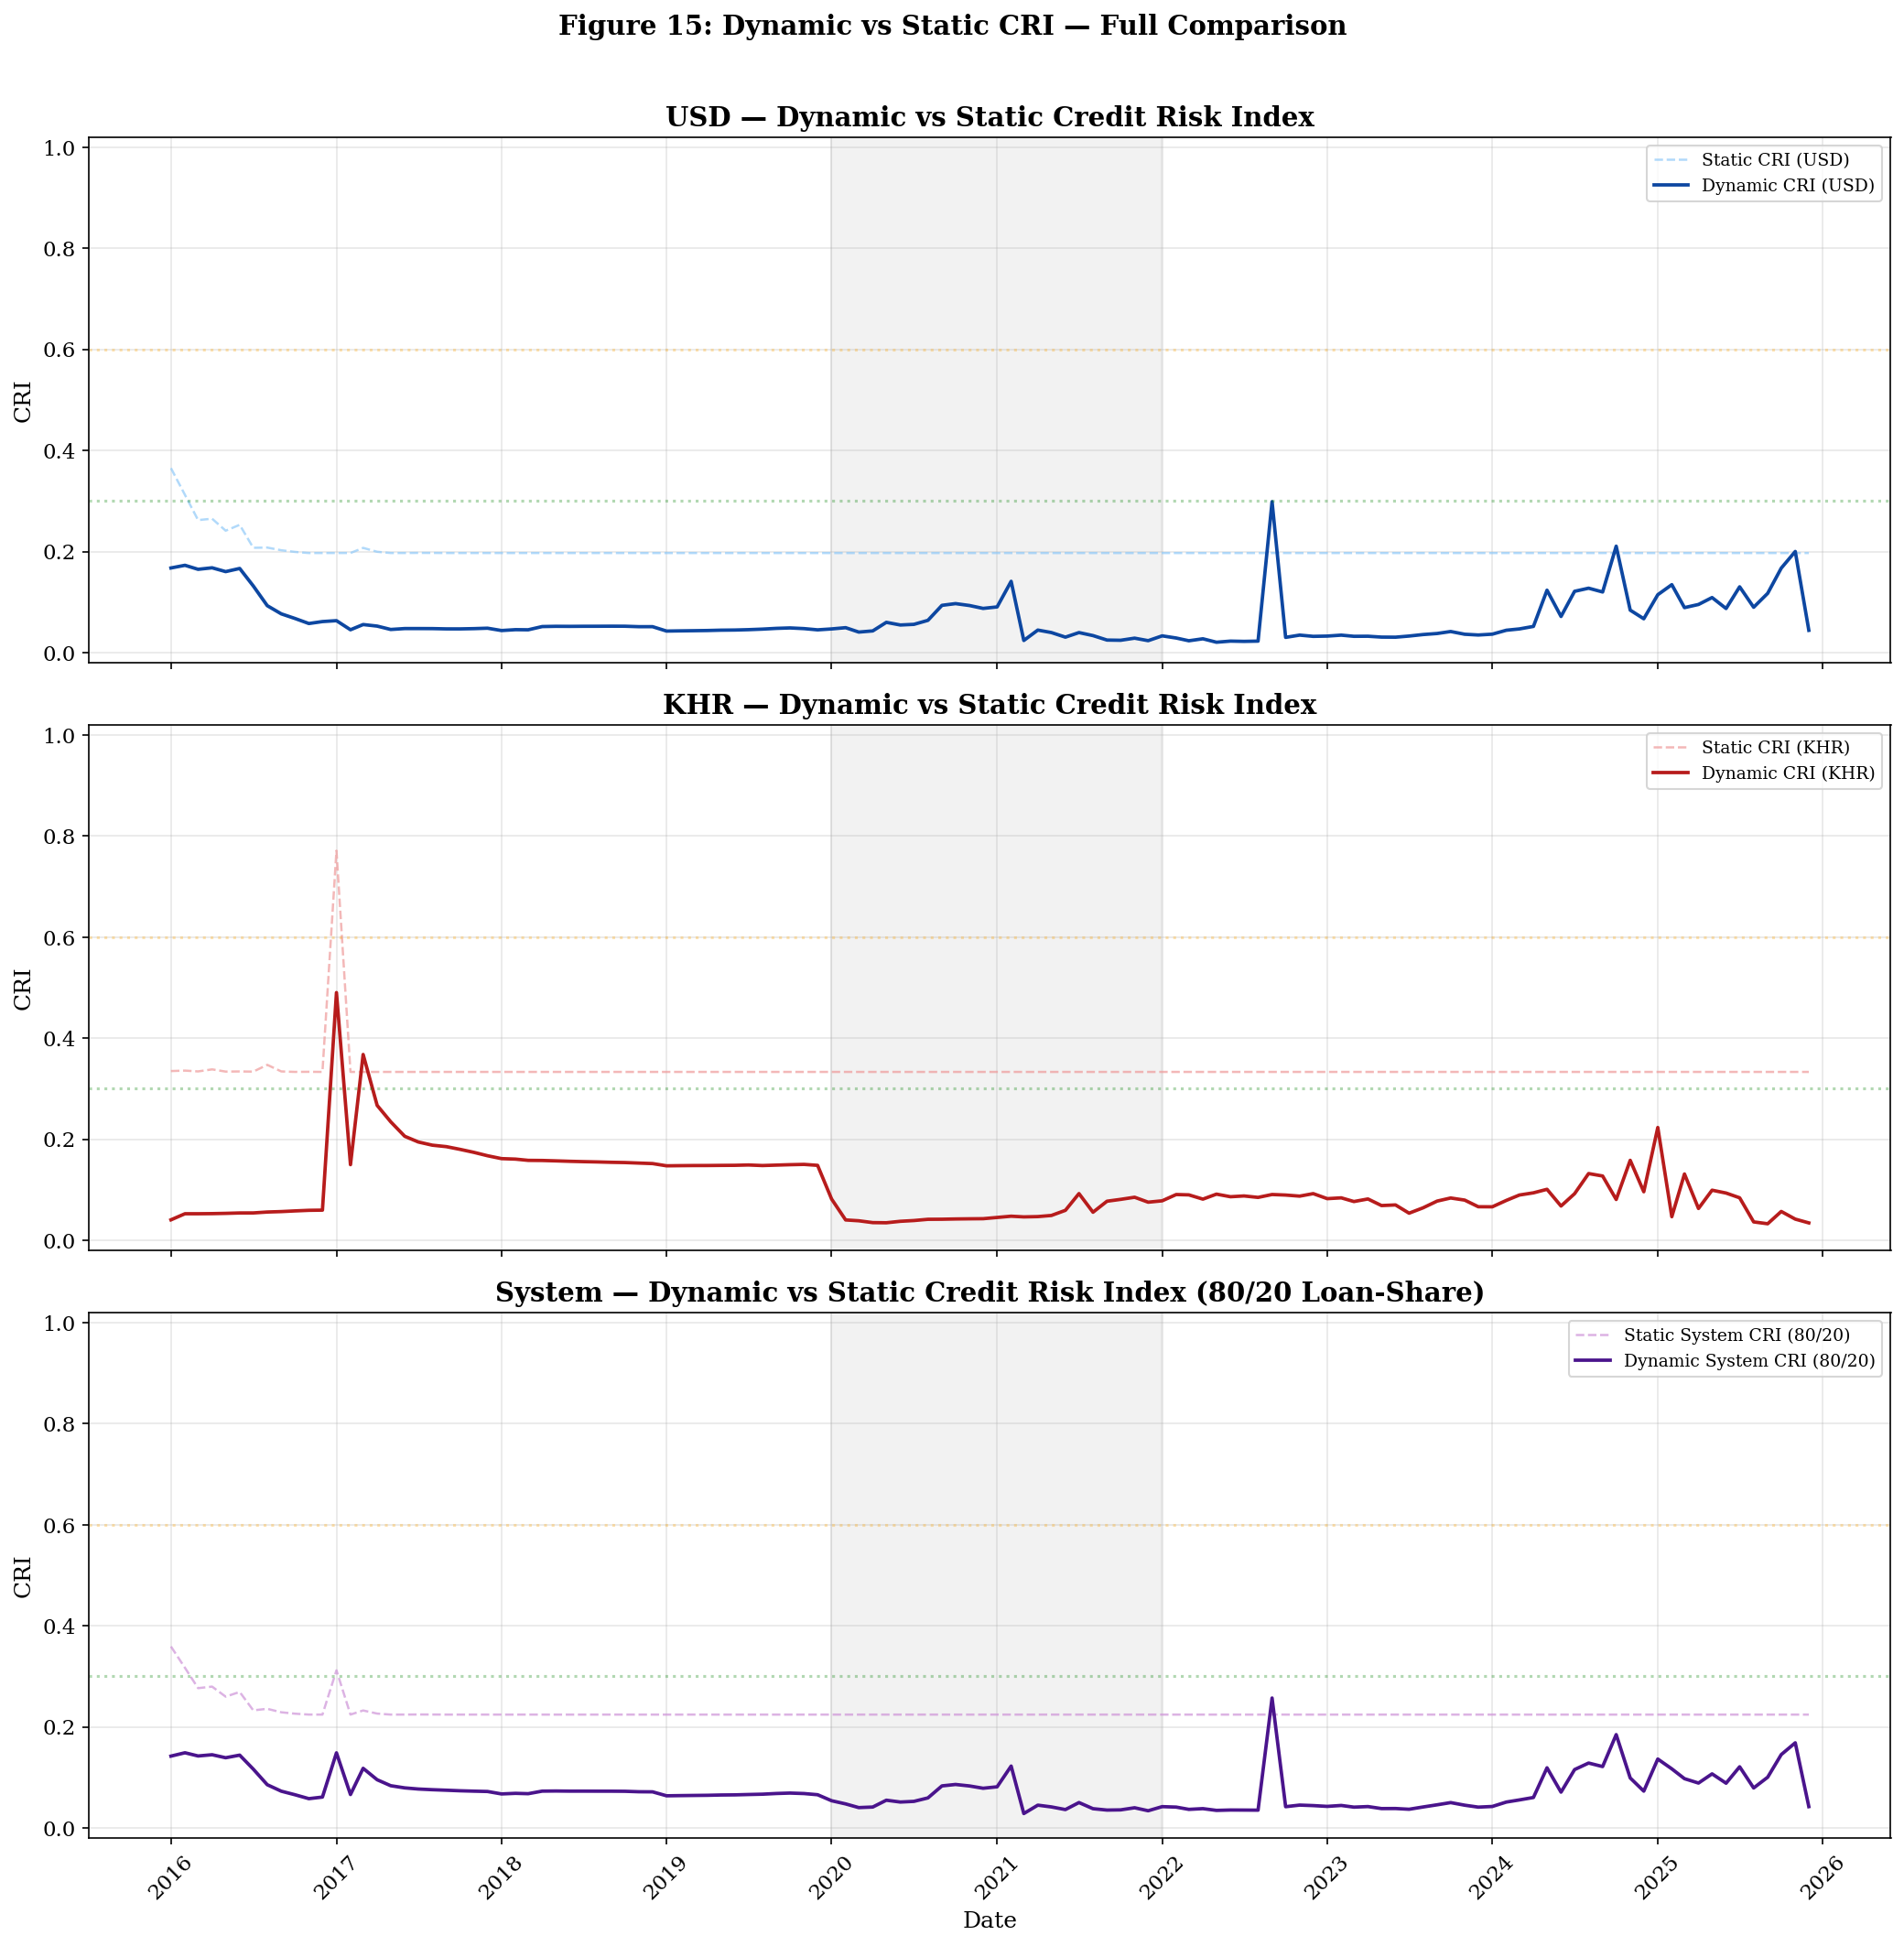

Saved: fig15_dynamic_vs_static_cri.png


In [8]:
# ─── Figure: Dynamic vs Static CRI Comparison ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# USD
axes[0].plot(dyn_dates, CRI_static_usd, color='#90CAF9', linewidth=1.2, alpha=0.7, linestyle='--', label='Static CRI (USD)')
axes[0].plot(dyn_dates, CRI_dyn_usd, color='#0D47A1', linewidth=1.8, label='Dynamic CRI (USD)')
axes[0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
axes[0].axhline(y=0.3, color='green', linestyle=':', alpha=0.3)
axes[0].axhline(y=0.6, color='orange', linestyle=':', alpha=0.3)
axes[0].set_title('USD — Dynamic vs Static Credit Risk Index', fontweight='bold')
axes[0].set_ylabel('CRI')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.02, 1.02)

# KHR
axes[1].plot(dyn_dates, CRI_static_khr, color='#EF9A9A', linewidth=1.2, alpha=0.7, linestyle='--', label='Static CRI (KHR)')
axes[1].plot(dyn_dates, CRI_dyn_khr, color='#B71C1C', linewidth=1.8, label='Dynamic CRI (KHR)')
axes[1].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
axes[1].axhline(y=0.3, color='green', linestyle=':', alpha=0.3)
axes[1].axhline(y=0.6, color='orange', linestyle=':', alpha=0.3)
axes[1].set_title('KHR — Dynamic vs Static Credit Risk Index', fontweight='bold')
axes[1].set_ylabel('CRI')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.02, 1.02)

# System
axes[2].plot(dyn_dates, CRI_static_sys, color='#CE93D8', linewidth=1.2, alpha=0.7, linestyle='--', label='Static System CRI (80/20)')
axes[2].plot(dyn_dates, CRI_dyn_sys, color='#4A148C', linewidth=1.8, label='Dynamic System CRI (80/20)')
axes[2].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
axes[2].axhline(y=0.3, color='green', linestyle=':', alpha=0.3)
axes[2].axhline(y=0.6, color='orange', linestyle=':', alpha=0.3)
axes[2].set_title('System — Dynamic vs Static Credit Risk Index (80/20 Loan-Share)', fontweight='bold')
axes[2].set_ylabel('CRI')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.02, 1.02)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

fig.suptitle('Figure 15: Dynamic vs Static CRI — Full Comparison', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig15_dynamic_vs_static_cri.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig15_dynamic_vs_static_cri.png')

### Interpretation — Dynamic vs Static CRI

The most recent CRI values tell the complete story:

| Currency | Dynamic CRI | Static CRI | Ratio |
|----------|:-----------:|:----------:|:-----:|
| USD | **0.044** | 0.197 | 0.22× |
| KHR | **0.035** | 0.333 | 0.10× |
| System (80/20) | **0.043** | 0.225 | 0.19× |

The dynamic CRI is dramatically lower than the static version because it uses **rolling σ and rolling thresholds** that adapt to the current low-volatility, low-spread regime. The static version's inflated floor comes from the full-sample σ (which averages across the high-volatility early period).

**Three Key Behaviors:**

1. **2016–2017 (High-Risk Era):** Both versions agree — CRI is elevated, with dynamic potentially showing even more extreme readings because the rolling parameters capture the high-volatility regime directly.

2. **2018–2019 (Transition):** Both decline, but the dynamic version drops faster as the rolling window moves past the high-spread observations.

3. **2020–2025 (Current):** Static CRI flatlines at ~0.20 (USD) and ~0.33 (KHR) — these are just the floor from the σ component, since crisis probability is zero. The dynamic CRI is lower but **responsive**, fluctuating around 0.04 and capturing relative spread movements.

**Recommendation for the Paper:** Present both versions as complementary tools. The static CRI answers _"How extreme is the current spread compared to the full 13-year history?"_ The dynamic CRI answers _"Is the spread elevated relative to recent conditions?"_ The latter is far more useful for operational monitoring and early warning.

In [9]:
# ─── Save Dynamic CRI Results ────────────────────────────────────────────────
cri_dyn_df = pd.DataFrame({
    'date': dyn_dates,
    'USD_spread': S_usd[window:window+n_roll],
    'KHR_spread': S_khr[window:window+n_roll],
    'Sc_rolling_USD': roll_Sc_usd[:n_roll],
    'Sc_rolling_KHR': roll_Sc_khr[:n_roll],
    'P_dyn_USD': P_dyn_usd,
    'P_dyn_KHR': P_dyn_khr,
    'CRI_dyn_USD': CRI_dyn_usd,
    'CRI_dyn_KHR': CRI_dyn_khr,
    'CRI_dyn_System': CRI_dyn_sys,
    'CRI_static_USD': CRI_static_usd,
    'CRI_static_KHR': CRI_static_khr,
    'CRI_static_System': CRI_static_sys
})
cri_dyn_df.to_csv('../data/processed/cri_dynamic.csv', index=False)

print('Saved: cri_dynamic.csv')
print(f'\nDynamic CRI — most recent values:')
print(f'  USD: {CRI_dyn_usd[-1]:.4f}  (static: {CRI_static_usd[-1]:.4f})')
print(f'  KHR: {CRI_dyn_khr[-1]:.4f}  (static: {CRI_static_khr[-1]:.4f})')
print(f'  System: {CRI_dyn_sys[-1]:.4f}  (static: {CRI_static_sys[-1]:.4f})')

Saved: cri_dynamic.csv

Dynamic CRI — most recent values:
  USD: 0.0444  (static: 0.1973)
  KHR: 0.0347  (static: 0.3333)
  System: 0.0425  (static: 0.2245)


---
## Summary

| Feature | Static CRI (NB04) | Dynamic CRI (this notebook) |
|---------|:------------------:|:---------------------------:|
| Threshold | Full-sample 95th percentile | Rolling 36-month 95th percentile |
| OU Parameters | Full-sample MLE | Rolling 36-month MLE |
| σ normalization | Full-sample σ | Rolling σ |
| Post-2018 sensitivity | Near-zero (dead indicator) | Active and responsive |
| Historical comparability | High (same baseline) | Lower (regime-dependent) |
| Early warning value | Low in current regime | **High** — adapts to conditions |
| Recommended use | Historical retrospective | **Real-time monitoring** |